# Reinforcement Learning

# 5. Gradient Methods

This notebook presents gradient methods, useful for learning in some environment with a large state space.

We use a neural network with a single hidden layer.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from model import TicTacToe, Nim, ConnectFour
from agent import Agent, OnlineEvaluation
from dynamic import ValueIteration

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

## Value gradient

We start with value-based methods. The neural network is a regressor that approximates the value function. Note that the model is supposed to be known, so that we don't need the action-value function.

In [4]:
class Regressor(nn.Module):
    """Neural network for value function approximation. Return the value of each state."""
    def __init__(self, model, hidden_size):
        if not hasattr(model, 'one_hot_encode'):
            raise ValueError("The environment must have a one-hot encoding of states.")   
        super(Regressor, self).__init__()
        self.model = model
        state = model.init_state()
        code = model.one_hot_encode(state)
        input_size = len(code)
        self.nn = nn.Sequential(
            nn.Linear(input_size, hidden_size), 
            nn.GELU(), 
            nn.Linear(hidden_size, 1))

    def forward(self, code):
        """Forward pass."""
        return self.nn(code)

In [5]:
game = TicTacToe()
regressor = Regressor(model=game, hidden_size=100)

state = game.state
# one-hot encoding
code = game.one_hot_encode(state)
# tensor
code = torch.tensor(code).float()
# forward pass
value = regressor.forward(code).detach()
# value of the state
print(value)

tensor([0.0130])


## To do

* Complete the method get_best_actions of the class ValueGradient. 
* Test the agent on TicTacToe, against (1) a random adversary and (2) a perfect adversary.
* Test the agent on ConnectFour, against (1) a random adversary and (2) an adversary with the one-step policy.
* Compare your results to another learning strategy (e.g., Monte-Carlo learning) and interpret the results.

In [6]:
class ValueGradient(OnlineEvaluation):
    """Agent learning by value gradient. The model is supposed to be known.
    
    Parameters
    ----------
    model : object of class Environment
        Model.
    player : int
        Player for games (1 or -1, default = default player of the game).
    gamma : float
        Discount rate (in [0, 1], default = 1).
    hidden_size : int
        Size of the hidden layer (default = 100).
    """
    def __init__(self, model, player=None, gamma=1, hidden_size=100):
        super(ValueGradient, self).__init__(model, player=player)  
        if not hasattr(model, "get_next_state"):
            raise ValueError("The model must be known, with a 'get_next_state' method.")
        self.nn = Regressor(model, hidden_size)
        self.gamma = gamma
        
    def get_best_actions(self, state):
        """Get the best actions in some state according to the value function.""" 
        actions = self.get_actions(state)
        if len(actions) > 1:
            # to be modified
            # if the state is terminal, take the actual value
            values = np.zeros(len(actions))
            for i, action in enumerate(actions):
                next_state = self.model.get_next_state(state, action)
                if self.model.is_terminal(next_state):
                    values[i] = self.model.get_reward(next_state)
                else:
                    code = self.model.one_hot_encode(next_state)
                    code = torch.tensor(code).float().reshape(1, -1)
                    values[i] = self.nn.forward(code).detach().numpy()
            if self.player == 1:
                best_value = max(values)
            else:
                best_value = min(values)
            actions = [action for action, value in zip(actions, values) if value==best_value]
        return actions        
    
    def update_policy(self):
        self.policy = self.get_policy()
    
    def get_samples(self, horizon, epsilon):
        """Get samples from one episode under the epsilon-greedy policy."""
        self.policy = self.randomize_policy(epsilon=epsilon)
        self.model.reset()
        state = self.model.state
        states = []
        rewards = []
        for t in range(horizon):
            action = self.get_action(state)
            reward, stop = self.model.step(action)
            states.append(state)
            rewards.append(reward)
            if stop:
                break
            state = self.model.state
        gains = []
        gain = 0
        for reward in reversed(rewards):
            gain = reward + self.gamma * gain
            gains.append(gain)
        return reversed(states), gains
        
    def train(self, horizon=100, n_episodes=1000, learning_rate=0.01, epsilon=0.1):
        """Train the neural network with samples drawn from the epsilon-greedy policy."""
        optimizer = optim.Adam(self.nn.parameters(), lr=learning_rate)
        for t in range(n_episodes):
            states, gains = self.get_samples(horizon, epsilon)
            codes = [self.model.one_hot_encode(state) for state in states]
            codes = np.array(codes)
            codes = torch.tensor(codes).float()
            values = self.nn.forward(codes)
            gains = torch.tensor(gains).float().reshape(-1, 1)
            mse = nn.MSELoss()
            loss = mse(values, gains)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

In [7]:
def run_training(Game, Agent, adversary_policy, n_episodes_total, n_episodes=1000, horizon=100, learning_rate=0.01, epsilon=0.1):
    """Run the training of an agent on a game."""
    game = Game(adversary_policy=adversary_policy)
    agent = Agent(game)
    
    step = n_episodes_total // n_episodes
    gains = []

    gain = agent.get_gains(n_runs=100)
    gains.append(np.mean(gain))
    for t in range(step):
        agent.train(horizon=horizon, n_episodes=n_episodes, learning_rate=learning_rate, epsilon=epsilon)
        agent.update_policy()
        gain = agent.get_gains(n_runs=100)
        gains.append(np.mean(gain))

    return gains

def plot_gains(n_episodes_total, n_episodes, gains, adversary, label):
    """Plot the gains."""
    plt.plot(range(0, n_episodes_total+1, n_episodes), gains, marker='o', label=label)
    plt.xlabel("Number of episodes")
    plt.ylabel("Gains")
    plt.ylim(-1, 1)
    # capitalize the first letter
    plt.title(f"{adversary.capitalize()} adversary")
    plt.legend()


In [8]:
n_episodes_total = 2500
n_episodes = 500

## TicTacToe: Value gradient

In [9]:
game = TicTacToe()

algo = ValueIteration(game)
policy, perfect_tictactoe = algo.get_perfect_players()

### Random adversary

In [10]:
all_gains = []

for i in range(3):
    game = TicTacToe
    agent = ValueGradient
    gains = run_training(game, agent, "random", n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

# Average the gains at each 1000 games
tictactoe_vg_random_average_gains = np.mean(all_gains, axis=0)

### Perfect adversary

In [11]:
all_gains = []

for i in range(3):
    game = TicTacToe
    agent = ValueGradient
    gains = run_training(game, agent, perfect_tictactoe, n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

# Average the gains at each 1000 games
tictactoe_vg_perfect_average_gains = np.mean(all_gains, axis=0)

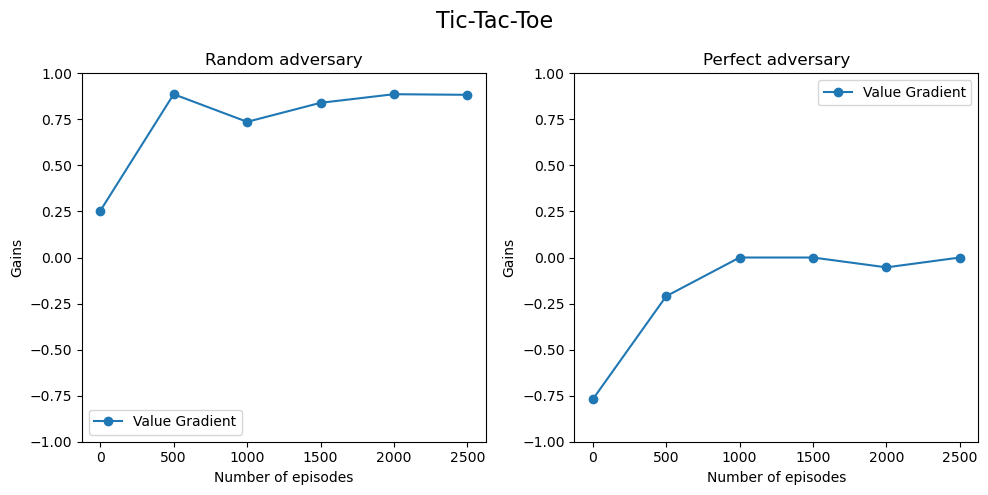

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot gains
plt.sca(axes[0])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_vg_random_average_gains, adversary="random", label="Value Gradient")

plt.sca(axes[1])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_vg_perfect_average_gains, adversary="perfect", label="Value Gradient")

fig.suptitle("Tic-Tac-Toe", fontsize=16)

plt.tight_layout()
plt.show()

## ConnectFour: Value gradient

### Random adversary

In [13]:
all_gains = []

for i in range(1):
    game = ConnectFour
    agent = ValueGradient
    gains = run_training(game, agent, "random", n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

# Average the gains at each 1000 games
connectfour_vg_random_average_gains = np.mean(all_gains, axis=0)

### One-step policy adversary

In [14]:
all_gains = []

for i in range(1):
    game = ConnectFour
    agent = ValueGradient
    gains = run_training(game, agent, 'one_step', n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

# Average the gains at each 1000 games
connectfour_vg_onestep_average_gains = np.mean(all_gains, axis=0)

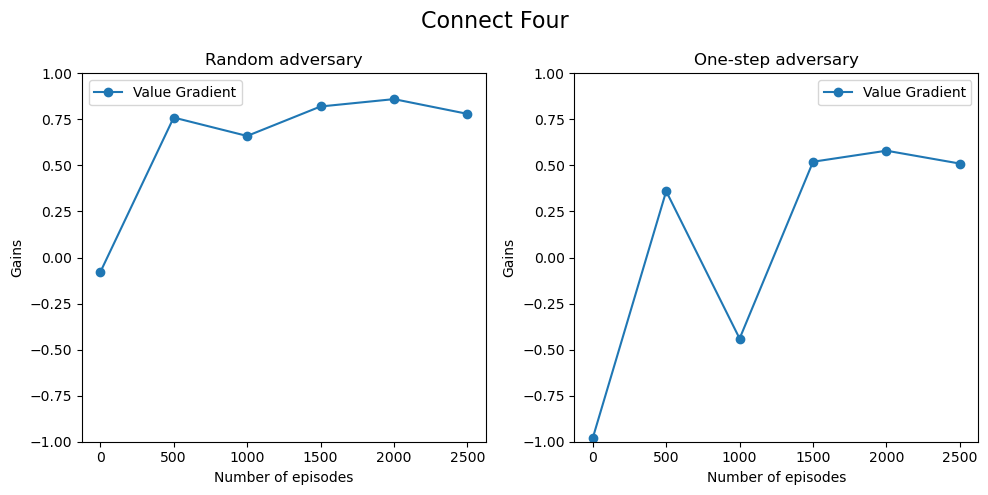

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot gains
plt.sca(axes[0])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_vg_random_average_gains, adversary="random", label="Value Gradient")

plt.sca(axes[1])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_vg_onestep_average_gains, adversary="one-step", label="Value Gradient")

fig.suptitle("Connect Four", fontsize=16)

plt.tight_layout()
plt.show()

## Value-gradient vs Monte-Carlo Learning

In [16]:
## Monte-Carlo learning
class MCLearning(OnlineEvaluation):
    """Online evaluation by Monte-Carlo."""
        
    def update_values(self, state=None, horizon=100):
        """Update the values from one episode."""
        stop, states, rewards = self.get_episode(state=state, horizon=horizon)
        states.pop()
        gain = 0
        # backward update
        for state, reward in zip(reversed(states), reversed(rewards)):
            self.add_state(state)
            code = self.model.encode(state)
            self.count[code] += 1
            # to be modified
            # begin
            gain = reward + self.gamma * gain
            # end 
            diff = gain - self.value[code]
            count = self.count[code]
            self.value[code] += diff / count
            

In [17]:
def run_training_mc(Game, Algo, adversary_policy, n_episodes_total, n_episodes=1000):
    """Run the training of a given agent on a given game."""
    game = Game(adversary_policy=adversary_policy)
    algo = Algo(game)

    step = n_episodes_total // n_episodes
    gains = []

    gain = algo.get_gains(n_runs=100)
    gains.append(np.mean(gain))
    for t in range(n_episodes_total):
        algo.update_values()

        if t % n_episodes == 0:
            policy_improved = algo.get_policy()
            agent = Agent(game, policy=policy_improved)
            gain = agent.get_gains(n_runs=100)
            gains.append(np.mean(gain))

    return gains

### TicTacToe

In [18]:
all_gains = []

for i in range(3):
    game = TicTacToe
    agent = MCLearning
    gains = run_training_mc(game, agent, adversary_policy='random', n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

tictactoe_mc_random_average_gains = np.mean(all_gains, axis=0)

In [19]:
all_gains = []

for i in range(1):
    game = TicTacToe
    agent = MCLearning
    gains = run_training_mc(game, agent, adversary_policy=perfect_tictactoe, n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

tictactoe_mc_perfect_average_gains = np.mean(all_gains, axis=0)

### ConnectFour

In [20]:
all_gains = []

for i in range(1):
    game = ConnectFour
    agent = MCLearning
    gains = run_training_mc(game, agent, adversary_policy="random", n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

connectfour_mc_random_average_gains = np.mean(all_gains, axis=0)

In [21]:
all_gains = []

for i in range(1):
    game = ConnectFour
    agent = MCLearning
    gains = run_training_mc(game, agent, adversary_policy="one_step", n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

connectfour_mc_onestep_average_gains = np.mean(all_gains, axis=0)

### Comparison

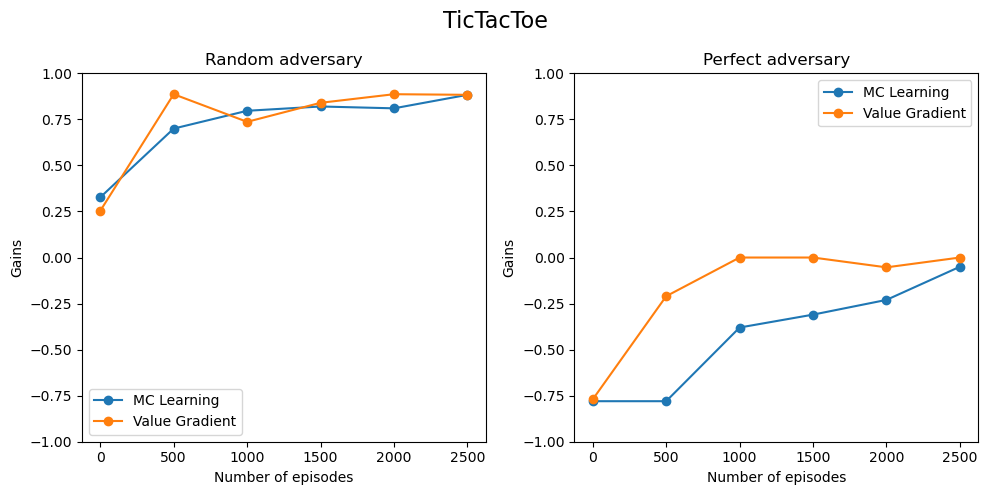

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot gains
plt.sca(axes[0])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_mc_random_average_gains, adversary="random", label="MC Learning")
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_vg_random_average_gains, adversary="random", label="Value Gradient")

plt.sca(axes[1])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_mc_perfect_average_gains, adversary="perfect", label="MC Learning")
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_vg_perfect_average_gains, adversary="perfect", label="Value Gradient")

fig.suptitle("TicTacToe", fontsize=16)

plt.tight_layout()
plt.show()

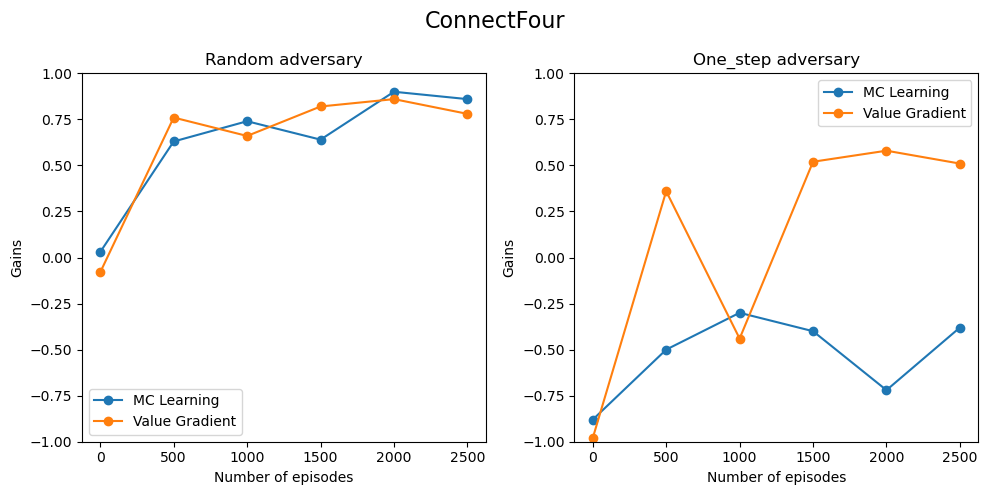

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot gains
plt.sca(axes[0])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_mc_random_average_gains, adversary="random", label="MC Learning")
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_vg_random_average_gains, adversary="random", label="Value Gradient")

plt.sca(axes[1])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_mc_onestep_average_gains, adversary="one_step", label="MC Learning")
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_vg_onestep_average_gains, adversary="one_step", label="Value Gradient")

fig.suptitle("ConnectFour", fontsize=16)

plt.tight_layout()
plt.show()

**Interpretation**

The results show that the Value Gradient method consistently outperforms Monte Carlo (MC) Learning, particularly in the early stages of training. This advantage is evident across both TicTacToe and ConnectFour, where Value Gradient shows faster convergence and higher gains, especially when facing more challenging adversaries. Against random adversaries, both algorithms eventually achieve similar results. Against a perfect player in TicTacToe or a one-step adversary in ConnectFour—Value Gradient shows a lead through the episodes, while MC Learning struggles to make progress. These results suggest that Value Gradient is more efficient at handling complex scenarios with large state spaces.

## Policy gradient

We now consider a policy-based method. The neural network is a classifier that approximates the optimal policy. It returns the probability of each action.

In [24]:
class Classifier(nn.Module):
    """Neural network for policy gradient. Return the distribution of actions in each state."""
    def __init__(self, model, hidden_size):
        if not hasattr(model, 'one_hot_encode'):
            raise ValueError("The environment must have a one-hot encoding of states.")   
        super(Classifier, self).__init__()
        self.model = model
        actions = model.get_all_actions()
        if self.model.is_game():
            # remove action when passing
            actions.pop()
        self.actions = actions
        state = model.init_state()
        code = model.one_hot_encode(state)
        input_size = len(code)
        output_size = len(actions)
        self.nn = nn.Sequential(
            nn.Linear(input_size, hidden_size), 
            nn.GELU(), 
            nn.Linear(hidden_size, output_size), 
            nn.Softmax(dim=0))

    def forward(self, code):
        """Forward pass."""
        return self.nn(code)

In [25]:
game = TicTacToe()
classifier = Classifier(model=game, hidden_size=100)

In [26]:
state = game.state
# one-hot encoding
code = game.one_hot_encode(state)
# tensor
code = torch.tensor(code).float()

probs = classifier.forward(code).detach()
print(probs)
len(probs)
torch.sum(probs)

tensor([0.1203, 0.1103, 0.1178, 0.0930, 0.1178, 0.1124, 0.1087, 0.1114, 0.1082])


tensor(1.)

## To do

* Complete the method 'train' of the class PolicyGradient. Observe that a penalty is assigned for illegal actions.
* Test the agent on TicTacToe, against (1) a random adversary and (2) a perfect adversary.
* Test the agent on ConnectFour, against (1) a random adversary and (2) an adversary with the one-step policy.
* Compare your results to another learning strategy (e.g., Monte-Carlo learning) and interpret the results.
* (bonus) Try to improve policy gradient on TicTacToe with a perfect adversary.

In [27]:
class PolicyGradient(Agent):
    """Agent learning by policy gradient.
    
    Parameters
    ----------
    model : object of class Environment
        Model.a
    player : int
        Player for games (1 or -1, default = default player of the game).
    gamma : float
        Discount rate (in [0, 1], default = 1).
    hidden_size : int
        Size of the hidden layer (default = 100).
    penalty : float
        Penalty for illegal actions (default = -5).
    min_log : float
        Minimal value to compute the log (default = 1e-10)
    """
    def __init__(self, model, player=None, gamma=1, hidden_size=100, penalty=-1, min_log=1e-10):
        super(PolicyGradient, self).__init__(model, player=player)  
        self.nn = Classifier(model, hidden_size)
        self.action_id = {action: i for i, action in enumerate(self.nn.actions)}
        self.gamma = gamma
        self.penalty = penalty
        self.min_log = min_log
        
    def get_policy(self):
        """Get the current policy."""
        def policy(state):
            actions = self.model.get_actions(state)
            if len(actions) > 1:
                win_actions = []
                # check win actions
                if self.model.is_game():
                    next_states = [self.model.get_next_state(state, action) for action in actions]
                    win_actions = [self.model.get_reward(next_state) == self.player for next_state in next_states]
                if any(win_actions):
                    probs = np.array(win_actions).astype(float)
                else:
                    # get prob of each action
                    code = self.model.one_hot_encode(state)
                    code = torch.tensor(code).float()
                    probs = self.nn.forward(code)
                    probs = probs.detach().numpy()
                    # restrict to available actions
                    indices = [self.action_id[action] for action in actions]
                    probs = probs[indices]                    
                # renormalize
                if np.sum(probs) > 0:
                    probs = probs / np.sum(probs)
                else:
                    probs = np.ones(len(actions)) / len(actions)
            else:
                probs = [1]
            return probs, actions
        return policy
    
    def update_policy(self):
        """Update the policy."""
        self.policy = self.get_policy()
    
    def get_samples(self, horizon):
        """Get samples from one episode."""
        self.update_policy()
        rewards = []
        log_probs = []
        log_probs_illegal = []
        self.model.reset()
        state = self.model.state
        for t in range(horizon):
            action = self.get_action(state)
            if action is not None:
                i = self.action_id[action]
                code = self.model.one_hot_encode(state)
                code = torch.tensor(code).float()
                probs = self.nn.forward(code)
                prob = torch.clip(probs[i], self.min_log, 1 - self.min_log)
                log_prob = torch.log(prob).reshape(1)

                actions = self.model.get_actions(state)
                if action in actions:
                    reward, stop = self.model.step(action)
                    state = self.model.state
                    rewards.append(reward)
                    log_probs.append(log_prob)
                else:
                    log_probs_illegal.append(log_prob)
            else:
                reward, stop = self.model.step(action)
                state = self.model.state
            if stop:
                break
        gain = 0
        for reward in reversed(rewards):
            gain = reward + self.gamma * gain
        return gain, log_probs, log_probs_illegal
        
    def train(self, horizon=100, n_episodes=1000, learning_rate=0.01):
        """Train the neural network."""
        optimizer = optim.Adam(self.nn.parameters(), lr=learning_rate)
        for t in range(n_episodes):
            gain, log_probs, log_probs_illegal = self.get_samples(horizon)
            loss = 0
            
            if len(log_probs):
                for log_prob in log_probs:
                    loss += - log_prob * gain

            if len(log_probs_illegal):
                for log_prob in log_probs_illegal:
                    loss += self.penalty * log_prob

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()


In [28]:
def run_training_pg(Game, Agent, adversary_policy, n_episodes_total, n_episodes):
    game = Game(adversary_policy=adversary_policy)
    agent = Agent(game)

    step = n_episodes_total // n_episodes
    gains = []
    
    gain = agent.get_gains(n_runs=100)
    gains.append(np.mean(gain))
    for t in range(step):
        agent.train(n_episodes=n_episodes)
        agent.update_policy()
        gain = agent.get_gains(n_runs=100)
        gains.append(np.mean(gain))

    return gains

In [29]:
n_episodes_total = 2500
n_episodes = 500

## TicTacToe: Value-gradient vs Monte-Carlo Learning

### Random adversary

In [30]:
all_gains = []

for i in range(3):
    game = TicTacToe
    agent = PolicyGradient
    gains = run_training_pg(game, agent, "random", n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

tictactoe_pg_random_average_gains = np.mean(all_gains, axis=0)

### Perfect adversary

In [31]:
all_gains = []

for i in range(3):
    game = TicTacToe
    agent = PolicyGradient
    gains = run_training_pg(game, agent, perfect_tictactoe, n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

tictactoe_pg_perfect_average_gains = np.mean(all_gains, axis=0)

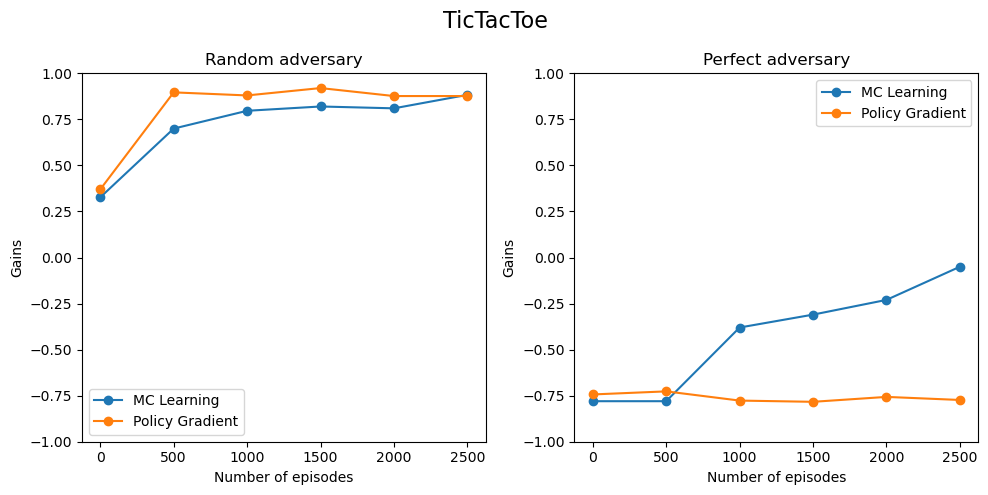

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot gains
plt.sca(axes[0])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_mc_random_average_gains, adversary="random", label="MC Learning")
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_pg_random_average_gains, adversary="random", label="Policy Gradient")

plt.sca(axes[1])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_mc_perfect_average_gains, adversary="perfect", label="MC Learning")
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=tictactoe_pg_perfect_average_gains, adversary="perfect", label="Policy Gradient")

fig.suptitle("TicTacToe", fontsize=16)  

plt.tight_layout()
plt.show()

## ConnectFour: Value-gradient vs Monte-Carlo Learning

### Random adversary

In [33]:
all_gains = []

for i in range(1):
    game = ConnectFour
    agent = PolicyGradient
    gains = run_training_pg(game, agent, "random", n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

connectfour_pg_random_average_gains = np.mean(all_gains, axis=0)

### One-step adversary

In [34]:
all_gains = []

for i in range(1):
    game = ConnectFour
    agent = PolicyGradient
    gains = run_training_pg(game, agent, "one_step", n_episodes_total=n_episodes_total, n_episodes=n_episodes)
    all_gains.append(gains)

connectfour_pg_onestep_average_gains = np.mean(all_gains, axis=0)

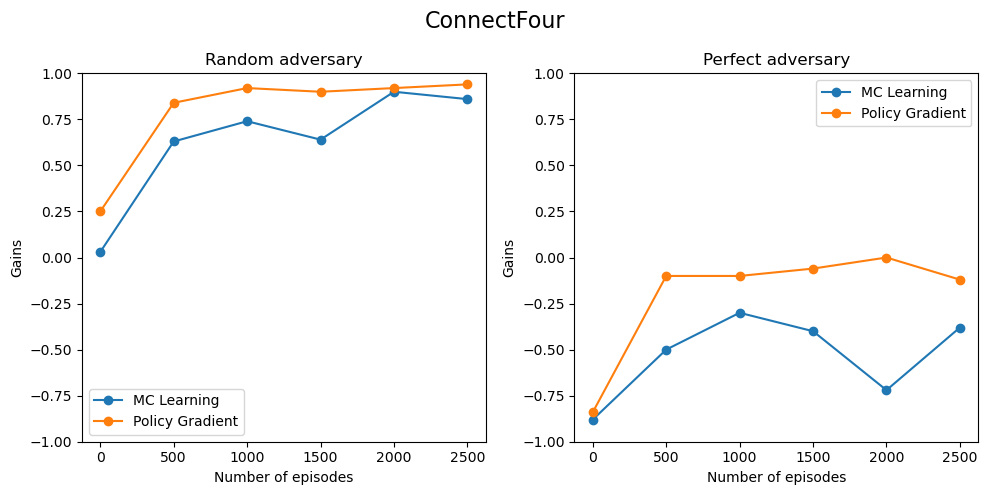

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot gains
plt.sca(axes[0])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_mc_random_average_gains, adversary="random", label="MC Learning")
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_pg_random_average_gains, adversary="random", label="Policy Gradient")

plt.sca(axes[1])
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_mc_onestep_average_gains, adversary="perfect", label="MC Learning")
plot_gains(n_episodes_total=n_episodes_total, n_episodes=n_episodes, gains=connectfour_pg_onestep_average_gains, adversary="perfect", label="Policy Gradient")

fig.suptitle("ConnectFour", fontsize=16)  

plt.tight_layout()
plt.show()

**Interpretation**

The results compare Monte Carlo (MC) learning and Policy Gradient in Tic Tac Toe and Connect Four against random and perfect adversaries. Against random adversaries, Policy Gradient achieves faster convergence and higher gains early on, but MC learning catches up over time. However, against perfect adversaries in TicTacToe Policy Gradient does not perform well. It could be that centering the gradient would make it perform better. In ConnectFour there is no problem with Policy Gradient and it outperforms MC learning significantly. Reaching optimal performance (gain of 0) against a perfect player.